# Week 6 Capstone: End-to-End Data Science Pipeline
This notebook implements the full project: data acquisition, cleaning, EDA, supervised regression, validation, and unsupervised segmentation using the public scikit-learn Diabetes dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

SEED=42
diab=load_diabetes(as_frame=True, scaled=False)
df=diab.frame.copy()
features=diab.feature_names
X=df[features]
y=df['target']
print(df.shape)
df.head()

(442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


## 1. Data quality and preprocessing

In [2]:
print('Missing values:', int(df.isna().sum().sum()))
print('Duplicate rows:', int(df.duplicated().sum()))
print(df.describe().T)

Missing values: 0
Duplicate rows: 0
        count        mean        std  ...        50%       75%      max
age     442.0   48.518100  13.109028  ...   50.00000   59.0000   79.000
sex     442.0    1.468326   0.499561  ...    1.00000    2.0000    2.000
bmi     442.0   26.375792   4.418122  ...   25.70000   29.2750   42.200
bp      442.0   94.647014  13.831283  ...   93.00000  105.0000  133.000
s1      442.0  189.140271  34.608052  ...  186.00000  209.7500  301.000
s2      442.0  115.439140  30.413081  ...  113.00000  134.5000  242.400
s3      442.0   49.788462  12.934202  ...   48.00000   57.7500   99.000
s4      442.0    4.070249   1.290450  ...    4.00000    5.0000    9.090
s5      442.0    4.641411   0.522391  ...    4.62005    4.9972    6.107
s6      442.0   91.260181  11.496335  ...   91.00000   98.0000  124.000
target  442.0  152.133484  77.093005  ...  140.50000  211.5000  346.000

[11 rows x 8 columns]


The modeling pipelines use median imputation and standardization where scale-sensitive models require it. The tree ensemble receives imputed numeric inputs but does not require feature scaling.

## 2. Exploratory data analysis

bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s3    -0.394789
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
Name: target, dtype: float64


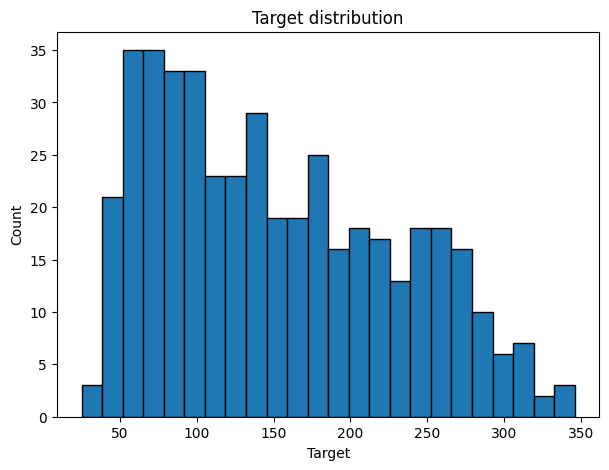

In [3]:
corr=df.corr(numeric_only=True)['target'].drop('target').sort_values(key=np.abs, ascending=False)
print(corr)
plt.figure(figsize=(7,5)); plt.hist(y,bins=24,edgecolor='black'); plt.title('Target distribution'); plt.xlabel('Target'); plt.ylabel('Count'); plt.show()

## 3. Supervised regression models

In [4]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=SEED)
prep=Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())])
models={
 'Linear Regression':Pipeline([('prep',prep),('model',LinearRegression())]),
 'Ridge Regression':Pipeline([('prep',prep),('model',Ridge(alpha=1.0))]),
 'Random Forest':Pipeline([('prep',SimpleImputer(strategy='median')),('model',RandomForestRegressor(n_estimators=500,random_state=SEED,min_samples_leaf=3,n_jobs=-1))])
}
rows=[]
for name,model in models.items():
 model.fit(X_train,y_train); p=model.predict(X_test)
 rows.append([name,mean_absolute_error(y_test,p),mean_squared_error(y_test,p)**0.5,r2_score(y_test,p)])
print(pd.DataFrame(rows,columns=['model','MAE','RMSE','R2']).sort_values('R2',ascending=False))

               model        MAE       RMSE        R2
1   Ridge Regression  42.811999  53.777454  0.454147
0  Linear Regression  42.794095  53.853446  0.452603
2      Random Forest  43.704925  53.916346  0.451323


## 4. Five-fold cross-validation

In [5]:
cv=KFold(n_splits=5,shuffle=True,random_state=SEED)
rows=[]
for name,model in models.items():
 sc=cross_validate(model,X,y,cv=cv,scoring={'r2':'r2','mae':'neg_mean_absolute_error','rmse':'neg_root_mean_squared_error'},n_jobs=-1)
 rows.append([name,sc['test_r2'].mean(),sc['test_r2'].std(),-sc['test_mae'].mean(),-sc['test_rmse'].mean()])
print(pd.DataFrame(rows,columns=['model','CV_R2_mean','CV_R2_std','CV_MAE_mean','CV_RMSE_mean']).sort_values('CV_R2_mean',ascending=False))

               model  CV_R2_mean  CV_R2_std  CV_MAE_mean  CV_RMSE_mean
1   Ridge Regression    0.479072   0.083413    44.243473     54.827054
0  Linear Regression    0.478470   0.084967    44.269746     54.848941
2      Random Forest    0.434629   0.092541    46.382794     57.189865


## 5. Unsupervised segmentation

In [6]:
Xs=StandardScaler().fit_transform(X)
cluster_rows=[]
for k in range(2,7):
 km=KMeans(n_clusters=k,random_state=SEED,n_init=20); lab=km.fit_predict(Xs)
 cluster_rows.append([k,km.inertia_,silhouette_score(Xs,lab)])
cluster_eval=pd.DataFrame(cluster_rows,columns=['k','inertia','silhouette'])
print(cluster_eval)
best_k=int(cluster_eval.loc[cluster_eval.silhouette.idxmax(),'k'])
print('Selected k:',best_k)
km=KMeans(n_clusters=best_k,random_state=SEED,n_init=20)
labels=km.fit_predict(Xs)
print(pd.Series(labels).value_counts().sort_index())

   k      inertia  silhouette
0  2  3176.654907    0.236987
1  3  2879.211235    0.153473
2  4  2639.973695    0.140406
3  5  2453.238587    0.146746
4  6  2303.935401    0.143964
Selected k: 2
0    214
1    228
Name: count, dtype: int64


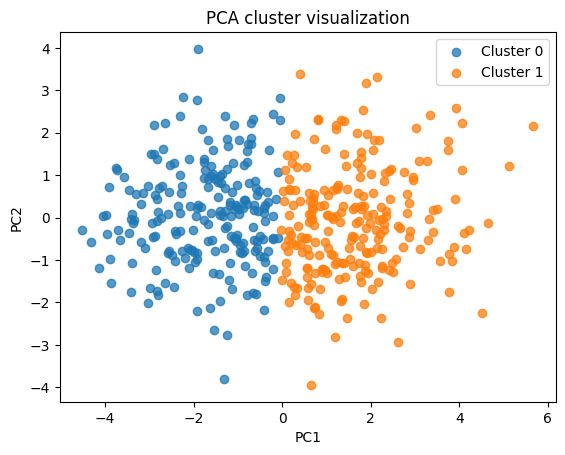

In [7]:
pca=PCA(n_components=2,random_state=SEED)
z=pca.fit_transform(Xs)
for c in sorted(np.unique(labels)):
 mask=labels==c; plt.scatter(z[mask,0],z[mask,1],alpha=.75,label=f'Cluster {c}')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('PCA cluster visualization'); plt.legend(); plt.show()

## 6. Conclusions

The capstone combines predictive modeling with unsupervised segmentation. Regression performance is judged with MAE, RMSE and R², while segmentation is assessed with inertia and silhouette score. The final discussion emphasizes that the dataset is suitable for demonstrating a workflow, not for clinical diagnosis or individual medical decision-making.